# `ReduCNN` Research Suite: CIFAR-100 📊

This notebook executes structural pruning experiments on the **CIFAR-100** dataset. With 100 classes and limited samples per class, this experiment evaluates the framework's pruning stability in high-cardinality, low-data scenarios.

### ✨ ReduCNN v0.6.6 Features:
1. **Architecture Agnostic**: Support for ResNet, DenseNet, and complex DAG models via automatic dependency discovery.
2. **Surgical Pruning Clusters**: Identifies coupled layers that must be pruned together to maintain structural integrity.
3. **Advanced Visualizations**: Introducing the **'X-Ray'** visualizer for interactive dependency mapping.
4. **Hybrid Meta-Pruning**: SOTA data-driven pruning based on literature-grounded criteria.

## Notebook Guide
Recommended run order for presentation:
1. Bootloader and dataset setup
2. Baseline training and evaluation
3. Pruning run (produce `pruned_model` and `masks`)
4. Presentation Mode diagnostics section at the end


In [18]:
# --- STEP 0: BOOTLOADER ---
import sys, os
if os.path.exists('src'): sys.path.insert(0, os.path.abspath('src'))

try:
    import reducnn
    print(f"✅ ReduCNN v{reducnn.__version__} loaded from: {reducnn.__file__}")
    import reducnn.visualization as viz
    from reducnn.visualization.animator import PruningAnimator
except ImportError:
    print("❌ ReduCNN not found in path. Please ensure you are in the project root.")

In [ ]:
# --- GLOBAL EXPERIMENT CONFIGURATION ---
MODEL_TYPE = 'vgg16'   # options: 'resnet18', 'vgg16', 'resnet50', 'densenet121'
DATASET_NAME = 'CIFAR-100'
INPUT_SHAPE = (3, 32, 32) 
NUM_CLASSES = 100

print(f"🚀 Experiment Configured: {MODEL_TYPE} on {DATASET_NAME}")

In [ ]:
# --- RUN ID + ARTIFACT PERSISTENCE (v0.88) ---
from pathlib import Path
from datetime import datetime
import os, re

def _slug(x):
    s = re.sub(r"\s+", "-", str(x or "").strip().lower())
    s = re.sub(r"[^a-z0-9_.-]", "", s)
    s = s.strip("-._")
    return s or "unknown"

DATASET_KEY = _slug(globals().get('DATASET_KEY') or globals().get('DATASET_NAME') or globals().get('dataset_name') or 'dataset')
MODEL_KEY = _slug(globals().get('MODEL_TYPE') or globals().get('model_type') or 'model')
RUN_ID = globals().get('RUN_ID') or f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_{DATASET_KEY}_{MODEL_KEY}"

OUTPUT_ARTIFACT_DIR = Path('outputs') / 'experiments' / DATASET_KEY / MODEL_KEY / RUN_ID
SAVED_ARTIFACT_DIR = Path('saved_models') / 'artifacts' / DATASET_KEY / MODEL_KEY / RUN_ID
OUTPUT_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
SAVED_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

os.environ['REDUCNN_RUN_ID'] = str(RUN_ID)
os.environ['REDUCNN_DATASET_KEY'] = str(DATASET_KEY)
os.environ['REDUCNN_ARTIFACT_DIR'] = str(OUTPUT_ARTIFACT_DIR)
os.environ['REDUCNN_ARTIFACT_MIRROR_DIR'] = str(SAVED_ARTIFACT_DIR)

print(f"Run ID: {RUN_ID}")
print(f"Artifacts: {OUTPUT_ARTIFACT_DIR}")
print(f"Artifacts mirror: {SAVED_ARTIFACT_DIR}")


In [ ]:
# --- Custom method registration (v0.88 unified: torch + keras) ---
from reducnn.pruner import register_method
import numpy as np

def _tools(kwargs):
    t = kwargs.get('tools', None)
    if t is None:
        raise ValueError('Backend tools not provided. Ensure adapter passes custom-method tools.')
    return t

def _max_batches(kwargs):
    val = kwargs.get('calib_batches', kwargs.get('prune_batches', kwargs.get('calibration_batches', None)))
    return int(val) if val else None

@register_method('custom_l2', framework='torch')
@register_method('custom_l2', framework='keras')
def custom_l2_score(layer, **kwargs):
    tools = _tools(kwargs)
    mode = str(kwargs.get('l2_mode', 'sum')).lower().strip()
    return np.asarray(tools.weight_l2(layer, mode=mode), dtype=np.float64).reshape(-1)

@register_method('chip', framework='torch')
@register_method('chip', framework='keras')
def chip_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return None
    max_spatial = kwargs.get('chip_max_spatial', None)
    return np.asarray(tools.chip_scores(A, max_spatial=max_spatial), dtype=np.float64).reshape(-1)

@register_method('custom_nisp', framework='torch')
@register_method('custom_nisp', framework='keras')
def custom_nisp_score(layer, **kwargs):
    tools = _tools(kwargs)
    lname = kwargs.get('layer_name', None)
    if lname is None:
        return np.asarray(tools.weight_l2(layer, mode='sum'), dtype=np.float64).reshape(-1)
    score_map = tools.nisp_score_map(max_batches=_max_batches(kwargs))
    s = score_map.get(lname, None)
    if s is None:
        return np.asarray(tools.weight_l2(layer, mode='sum'), dtype=np.float64).reshape(-1)
    return np.asarray(s, dtype=np.float64).reshape(-1)

@register_method('custom_spectral_energy', framework='torch')
@register_method('custom_spectral_energy', framework='keras')
def custom_spectral_energy_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode='sum'), dtype=np.float64).reshape(-1)
    max_fft_samples = int(kwargs.get('max_fft_samples', 32))
    return np.asarray(tools.spectral_energy_scores(A, max_samples=max_fft_samples), dtype=np.float64).reshape(-1)

print('Custom methods registered: custom_l2, chip, custom_nisp, custom_spectral_energy (torch+keras).')


In [ ]:
# --- CSV artifact persistence helper (v0.88) ---
import os
import shutil
from pathlib import Path
import pandas as pd

def _artifact_root():
    out = globals().get('OUTPUT_ARTIFACT_DIR', None)
    if out is None:
        out = os.environ.get('REDUCNN_ARTIFACT_DIR', None)
    if out is None:
        out = Path('outputs') / 'experiments' / 'unknown'
    return Path(out)

def _artifact_mirror_root():
    mir = globals().get('SAVED_ARTIFACT_DIR', None)
    if mir is None:
        mir = os.environ.get('REDUCNN_ARTIFACT_MIRROR_DIR', None)
    return Path(mir) if mir else None

def _to_df(obj):
    if isinstance(obj, pd.DataFrame):
        return obj
    if isinstance(obj, list) and len(obj) > 0 and isinstance(obj[0], dict):
        return pd.DataFrame(obj)
    if isinstance(obj, dict):
        try:
            return pd.DataFrame(obj)
        except Exception:
            return pd.DataFrame([obj])
    return None

def persist_notebook_tables(namespace, prefix='results'):
    run_id = str(globals().get('RUN_ID', os.environ.get('REDUCNN_RUN_ID', 'run')))
    out_root = _artifact_root() / 'tables'
    out_root.mkdir(parents=True, exist_ok=True)
    mir_root = _artifact_mirror_root()
    if mir_root is not None:
        (mir_root / 'tables').mkdir(parents=True, exist_ok=True)

    saved = []
    key_tokens = ('result', 'summary', 'report', 'metric', 'table', 'record', 'comparison')
    for name, obj in namespace.items():
        lname = str(name).lower()
        if name.startswith('_'):
            continue
        if not any(t in lname for t in key_tokens):
            continue
        df = _to_df(obj)
        if df is None or df.empty:
            continue
        f = out_root / f'{run_id}_{prefix}_{name}.csv'
        df.to_csv(f, index=False)
        if mir_root is not None:
            mf = (mir_root / 'tables') / f.name
            shutil.copy2(f, mf)
        saved.append(str(f))
    return saved


In [19]:
import torch, torchvision, torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

train_set = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128)

print(f"✅ CIFAR-100 ready with {len(train_set)} training samples.")

100%|██████████| 169M/169M [00:13<00:00, 12.6MB/s] 


✅ CIFAR-100 ready with 50000 training samples.


🔥 Training VGG16 Baseline on CIFAR-100...


[VGG16_CIFAR100] Epoch 1/5: 100%|██████████| 391/391 [00:33<00:00, 11.54it/s, loss=4.0750, acc=3.66%]


📊 Validation: Loss 3.9641, Acc 5.56%


[VGG16_CIFAR100] Epoch 2/5: 100%|██████████| 391/391 [00:33<00:00, 11.53it/s, loss=3.2848, acc=9.52%]


📊 Validation: Loss 3.5129, Acc 12.60%


...

📊 Validation: Loss 3.1259, Acc 19.10%


[VGG16_CIFAR100] Epoch 4/5: 100%|██████████| 391/391 [00:33<00:00, 11.59it/s, loss=2.9613, acc=22.92%]


📊 Validation: Loss 3.0464, Acc 22.17%


[VGG16_CIFAR100] Epoch 5/5: 100%|██████████| 391/391 [00:33<00:00, 11.53it/s, loss=2.8311, acc=28.86%]


📊 Validation: Loss 2.7678, Acc 26.88%


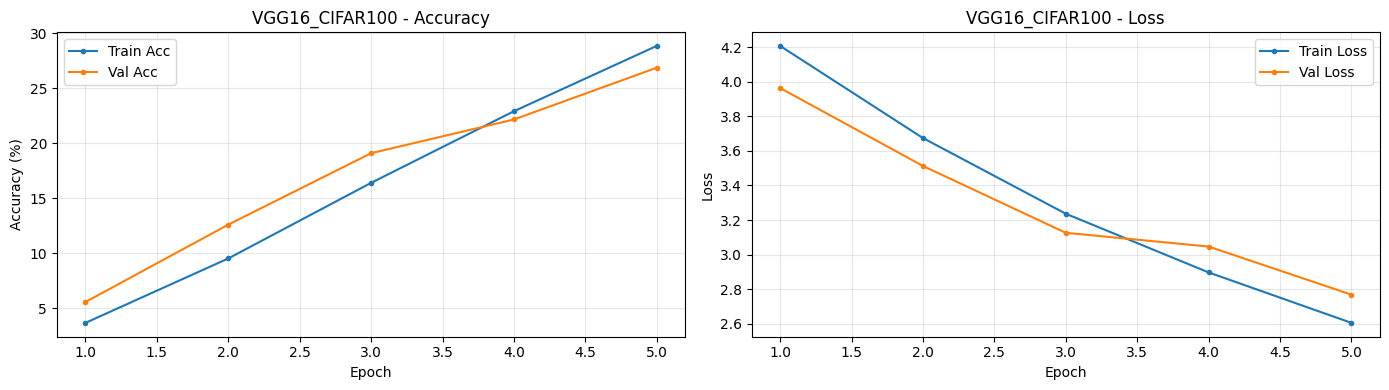

⏱️ train took 187.66s

✅ Baseline: 26.88%


In [20]:
from reducnn.backends.torch_backend import PyTorchAdapter
from reducnn.pruner import ReduCNNPruner

adapter = PyTorchAdapter(config={'lr': 1e-3, 'input_shape': (3, 32, 32), 'num_classes': 100})
model = adapter.get_model("vgg16")

print("🔥 Training VGG16 Baseline on CIFAR-100...")
adapter.train(model, train_loader, epochs=5, name="VGG16_CIFAR100", val_loader=test_loader)
b_acc = adapter.evaluate(model, test_loader)
print(f"\n✅ Baseline: {b_acc:.2f}%")

 PRUNING: L1-Norm (Local 30%)

--- Executing ReduCNN ---
🔍 Analyzing model using 'l1_norm' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
⏱️ prune took 0.07s
💊 Fine-tuning pruned model...


[Heal_L1_CIFAR100] Epoch 1/3: 100%|██████████| 391/391 [00:32<00:00, 11.88it/s, loss=2.2984, acc=33.07%]


📊 Validation: Loss 2.5877, Acc 31.56%


[Heal_L1_CIFAR100] Epoch 2/3: 100%|██████████| 391/391 [00:32<00:00, 12.10it/s, loss=2.2615, acc=38.50%]


📊 Validation: Loss 2.4837, Acc 32.70%


[Heal_L1_CIFAR100] Epoch 3/3: 100%|██████████| 391/391 [00:32<00:00, 11.98it/s, loss=1.8721, acc=43.32%]


📊 Validation: Loss 2.4071, Acc 36.69%


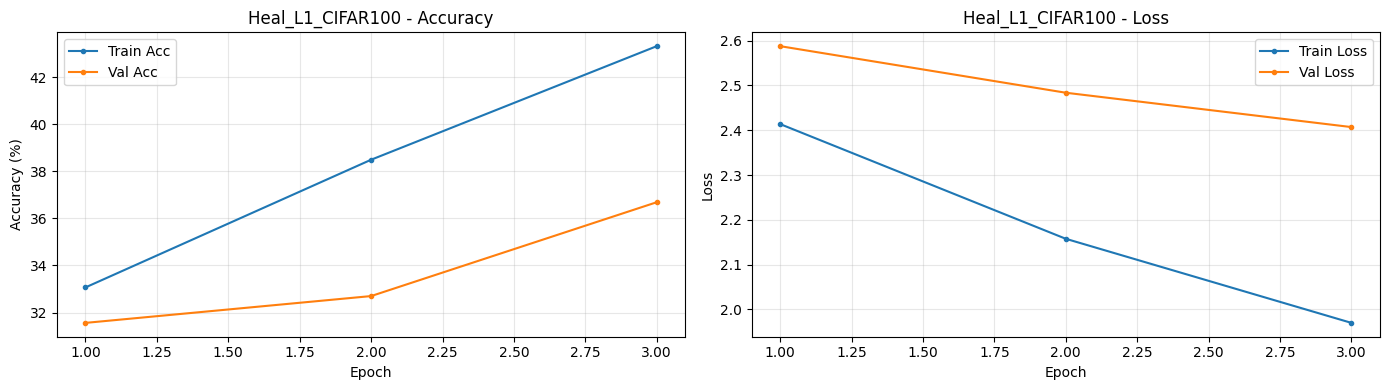

⏱️ train took 107.88s

✅ Pruned Accuracy: 36.69%


In [21]:
print(" PRUNING: L1-Norm (Local 30%)")
surgeon = ReduCNNPruner(method='l1_norm', scope='local')
pruned_model, masks, duration = surgeon.prune(model, train_loader, ratio=0.3)

print("💊 Fine-tuning pruned model...")
adapter.train(pruned_model, train_loader, epochs=3, name="Heal_L1_CIFAR100", val_loader=test_loader)
p_acc = adapter.evaluate(pruned_model, test_loader)
print(f"\n✅ Pruned Accuracy: {p_acc:.2f}%")

### C.1 PyTorch ResNet-18: Full Research Workflow (CIFAR-100)


🧪 PYTORCH: ResNet-18 Full Suite (CIFAR-100)
1. Establishing ResNet Baseline...


[ResNet_Base] Epoch 1/2: 100%|██████████| 391/391 [00:55<00:00,  7.06it/s, loss=3.3741, acc=15.02%]


📊 Validation: Loss 3.1916, Acc 23.06%


[ResNet_Base] Epoch 2/2: 100%|██████████| 391/391 [00:54<00:00,  7.17it/s, loss=2.6385, acc=28.83%]


📊 Validation: Loss 2.7740, Acc 30.07%


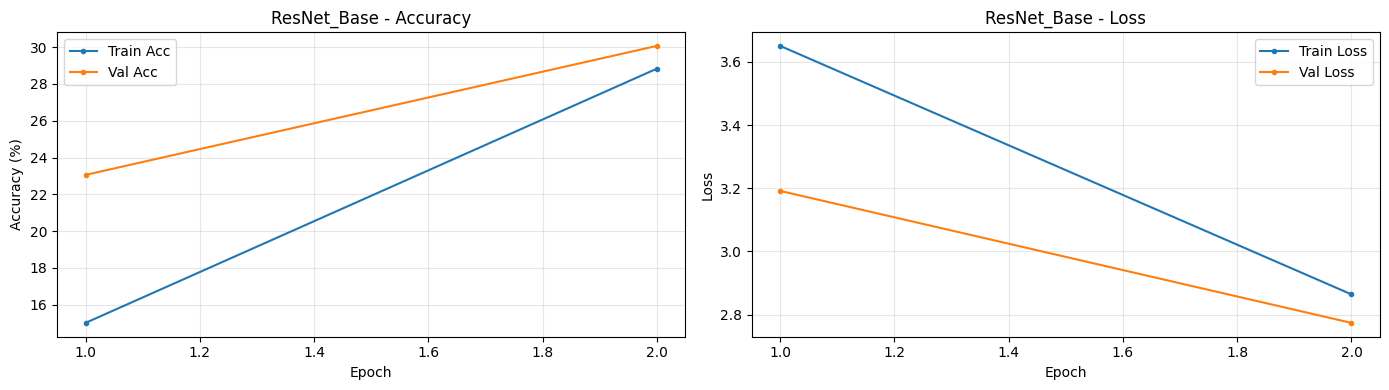

⏱️ train took 119.27s

2. Performing Structural Surgery (Local 20%)...

--- Executing ReduCNN ---
🔍 Analyzing model using 'l1_norm' method...
🏗️ Building masks (scope: local, ratio: 0.2)...
✂️ Applying physical surgery...
⏱️ prune took 0.06s

3. Healing Phase (Fine-tuning)...


[ResNet_Heal] Epoch 1/3: 100%|██████████| 391/391 [00:51<00:00,  7.59it/s, loss=2.3565, acc=30.86%]


📊 Validation: Loss 2.7043, Acc 31.26%


[ResNet_Heal] Epoch 2/3: 100%|██████████| 391/391 [00:51<00:00,  7.53it/s, loss=1.7899, acc=39.87%]


📊 Validation: Loss 2.4182, Acc 36.71%


[ResNet_Heal] Epoch 3/3: 100%|██████████| 391/391 [00:51<00:00,  7.56it/s, loss=1.8456, acc=47.21%]


📊 Validation: Loss 2.2644, Acc 40.79%


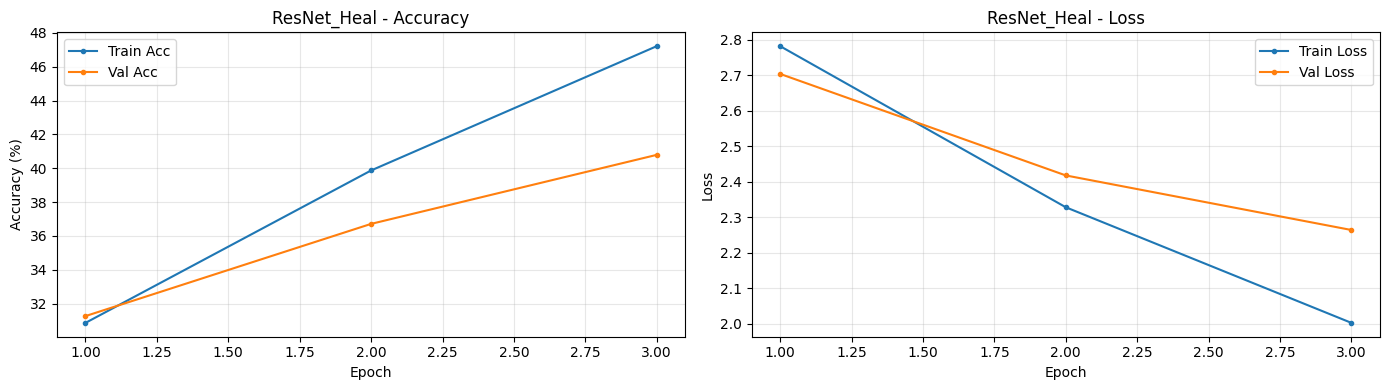

⏱️ train took 166.86s


NameError: name 'dataset_name' is not defined

In [22]:
dataset_name = 'CIFAR-100'
print(f'🧪 PYTORCH: ResNet-18 Full Suite ({dataset_name})')
t_res_adapter = PyTorchAdapter(config={'lr': 1e-4, 'input_shape': (3, 32, 32), 'num_classes': 100})
t_res_model = t_res_adapter.get_model('resnet18', pretrained=True)

print('1. Establishing ResNet Baseline...')
t_res_adapter.train(t_res_model, train_loader, epochs=2, name='ResNet_Base', val_loader=test_loader)
res_base_acc = t_res_adapter.evaluate(t_res_model, test_loader)

print('\n2. Performing Structural Surgery (Local 20%)...')
res_surgeon = ReduCNNPruner(method='l1_norm', scope='local')
pruned_res, res_masks, _ = res_surgeon.prune(t_res_model, train_loader, ratio=0.2)

print('\n3. Healing Phase (Fine-tuning)...')
t_res_adapter.train(pruned_res, train_loader, epochs=3, name='ResNet_Heal', val_loader=test_loader)
res_pruned_acc = t_res_adapter.evaluate(pruned_res, test_loader)

print(f'\n✅ ResNet-18 Results ({dataset_name}):')
print(f'   Baseline Acc: {res_base_acc:.2f}%')
print(f'   Pruned Acc:   {res_pruned_acc:.2f}%')
viz.plot_layer_sensitivity(res_masks, f'ResNet-18 Pruning Sensitivity ({dataset_name})')

### C.2 DenseNet-121: Concatenative Surgery & CHIP Method
DenseNet is a 'concatenative' architecture. ReduCNN must identify that pruning a layer affects not only its immediate output but all subsequent layers that receive its features via identity concatenation.

In [ ]:
print('🧪 PYTORCH: DenseNet-121 + CHIP Pruning')
t_dense_adapter = PyTorchAdapter(config={'lr': 1e-4, 'input_shape': (3, 32, 32), 'num_classes': 100})
t_dense_model = t_dense_adapter.get_model('densenet121')

print('1. Performing CHIP-based Pruning (Local 10%)...')
dense_surgeon = ReduCNNPruner(method='chip', scope='local')
pruned_dense, dense_masks, _ = dense_surgeon.prune(t_dense_model, train_loader, ratio=0.1)

print('\n2. Healing Phase (Fine-tuning)...')
t_dense_adapter.train(pruned_dense, train_loader, epochs=2, name='DenseNet_Heal', val_loader=test_loader)
dense_pruned_acc = t_dense_adapter.evaluate(pruned_dense, test_loader)
print(f'\n✅ DenseNet-121 Pruned Accuracy: {dense_pruned_acc:.2f}%')
viz.plot_layer_sensitivity(dense_masks, 'DenseNet-121 (CHIP) Sensitivity')

### C.3 The 'X-Ray' Visualizer: Understanding Structural Dependency
ReduCNN's `PruningAnimator` provides a 'deep look' into the model's structure. It maps out the dependency clusters identified during the discovery phase.

In [ ]:
print('🔍 Generating X-Ray Dependency Map...')
animator = PruningAnimator(t_res_adapter)

# 1. Show the Dependency Sweep (Discovery Phase)
animator.show_dependency_sweep(t_res_model)

# 2. Show the physical shrinkage planned for the model
animator.show_shrinkage(t_res_model, res_masks)

### C.4 Keras Implementation: VGG16 (CIFAR-100)
ReduCNN is backend-agnostic. Here we repeat the pruning experiment using the Keras backend.

In [ ]:
from reducnn.backends.keras_backend import KerasAdapter
print('🧪 KERAS: VGG16 Structural Pruning')

k_adapter = KerasAdapter(config={'lr': 1e-3, 'input_shape': INPUT_SHAPE, 'num_classes': NUM_CLASSES})
k_model = k_adapter.get_model('vgg16')

k_surgeon = ReduCNNPruner(method='l1_norm', scope='local')
k_pruned, k_masks, _ = k_surgeon.prune(k_model, train_loader, ratio=0.3)

print('\nHealing Keras model...')
k_adapter.train(k_pruned, train_loader, epochs=2, name='Keras_Heal', val_loader=test_loader)
k_acc = k_adapter.evaluate(k_pruned, test_loader)
print(f'\n✅ Keras Pruned Accuracy: {k_acc:.2f}%')

In [ ]:
import time
import torch
from pathlib import Path


def benchmark_inference(model, loader, device, iterations=100):
    model.eval()
    # Extract a single sample for latency test
    it = iter(loader)
    x, _ = next(it)
    x = x[:1].to(device)

    # Warm-up
    with torch.no_grad():
        for _ in range(20):
            _ = model(x)

    # Timing
    start = time.time()
    with torch.no_grad():
        for _ in range(iterations):
            _ = model(x)
    end = time.time()

    latency = (end - start) / iterations * 1000  # ms
    return latency


def _infer_num_classes(model, adapter):
    if hasattr(model, 'fc') and hasattr(model.fc, 'out_features'):
        return int(model.fc.out_features)

    classifier = getattr(model, 'classifier', None)
    if classifier is not None:
        if hasattr(classifier, 'out_features'):
            return int(classifier.out_features)
        if isinstance(classifier, torch.nn.Sequential) and len(classifier) > 0 and hasattr(classifier[-1], 'out_features'):
            return int(classifier[-1].out_features)

    return int(getattr(adapter, 'config', {}).get('num_classes', 10))


def _stats(adapter, model, loader):
    flops, params = adapter.get_stats(model, loader)
    return float(flops), float(params)


def _fmt_stats(flops, params):
    return f"FLOPs={flops/1e6:.2f}M, Params={params/1e6:.2f}M"


def _save_reload_and_verify_models(adapter, baseline_model, pruned_model, loader, tag):
    ckpt_dir = Path('exports/notebook_checkpoints')
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    baseline_ckpt = ckpt_dir / f"{tag}_resnet18_baseline_before_inference.pth"
    pruned_ckpt = ckpt_dir / f"{tag}_resnet18_pruned_before_inference.pth"

    adapter.save_checkpoint(baseline_model, str(baseline_ckpt))
    adapter.save_checkpoint(pruned_model, str(pruned_ckpt))

    num_classes = _infer_num_classes(baseline_model, adapter)
    baseline_loaded = adapter.get_model('resnet18', pretrained=False, num_classes=num_classes)
    pruned_loaded = adapter.get_model('resnet18', pretrained=False, num_classes=num_classes)

    adapter.load_checkpoint(baseline_loaded, str(baseline_ckpt))
    adapter.load_checkpoint(pruned_loaded, str(pruned_ckpt))

    b_flops_orig, b_params_orig = _stats(adapter, baseline_model, loader)
    p_flops_orig, p_params_orig = _stats(adapter, pruned_model, loader)
    b_flops_load, b_params_load = _stats(adapter, baseline_loaded, loader)
    p_flops_load, p_params_load = _stats(adapter, pruned_loaded, loader)

    print('💾 Saved checkpoints:')
    print(f'   Baseline -> {baseline_ckpt.resolve()}')
    print(f'   Pruned   -> {pruned_ckpt.resolve()}')

    print('🔎 Verifying FLOPs/Params on saved-and-reloaded models:')
    print(f'   Baseline (in-memory): {_fmt_stats(b_flops_orig, b_params_orig)}')
    print(f'   Baseline (reloaded):  {_fmt_stats(b_flops_load, b_params_load)}')
    print(f'   Pruned   (in-memory): {_fmt_stats(p_flops_orig, p_params_orig)}')
    print(f'   Pruned   (reloaded):  {_fmt_stats(p_flops_load, p_params_load)}')

    return baseline_loaded, pruned_loaded


print('💾 Saving + reloading baseline/pruned models before inference...')
eval_loader = test_loader
infer_baseline_model, infer_pruned_model = _save_reload_and_verify_models(
    t_res_adapter,
    t_res_model,
    pruned_res,
    eval_loader,
    tag='cifar100',
)

print('⏱️ Benchmarking Latency (Batch Size = 1) on reloaded models...')
t_orig = benchmark_inference(infer_baseline_model, eval_loader, t_res_adapter.device)
t_pruned = benchmark_inference(infer_pruned_model, eval_loader, t_res_adapter.device)

print(f'   Original ResNet Latency: {t_orig:.3f} ms')
print(f'   Pruned ResNet Latency:   {t_pruned:.3f} ms')
print(f'   🚀 Speedup: {(t_orig / t_pruned):.2f}x')


In [ ]:
print('🖼️ Generating Inference Gallery (using reloaded + verified checkpoints)...')
it = iter(eval_loader)
images, labels = next(it)
images_sub = images[:8]
labels_sub = labels[:8]

infer_baseline_model.eval()
infer_pruned_model.eval()
with torch.no_grad():
    p_orig = torch.argmax(infer_baseline_model(images_sub.to(t_res_adapter.device)), dim=1).cpu().numpy()
    p_pruned = torch.argmax(infer_pruned_model(images_sub.to(t_res_adapter.device)), dim=1).cpu().numpy()

class_names = None
viz.plot_inference_gallery(
    images_sub.numpy(),
    labels_sub.numpy(),
    p_orig,
    p_pruned,
    class_names=class_names,
    title='ResNet-18: Original vs. Pruned Predictions'
)


## Presentation Mode: Visual Diagnostics and Process Flow
This section is designed for demos and slides. It highlights:
1. Dependency graph and residual or concatenation clusters
2. Pruning candidate discovery (lowest-score channels)
3. Interactive X-ray graph walk (Discovery -> Importance -> Consistency -> Shrinkage)
4. Feature map visualization before and after pruning
5. Method agreement diagnostics (optional heavy step)


In [ ]:
# Presentation diagnostics utility (framework-agnostic, v0.6.6)
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import reducnn
import reducnn.visualization as viz
from reducnn.visualization.animator import PruningAnimator
from reducnn.analyzer.validator import MethodValidator

if tuple(map(int, reducnn.__version__.split('.'))) < (0, 6, 6):
    raise RuntimeError(f"Expected reducnn>=0.6.6, found {reducnn.__version__}")

def _resolve_from_globals(name_options):
    g = globals()
    for n in name_options:
        if n in g and g[n] is not None:
            return g[n], n
    return None, None

adapter, adapter_name = _resolve_from_globals(["adapter", "t_res_adapter", "k_adapter", "d_adapter", "dense_adapter"])
orig_model, model_name = _resolve_from_globals(["model", "t_res_model", "res_model", "dense_model", "d_model", "k_model"])
pruned_model, pruned_name = _resolve_from_globals(["pruned_model", "pruned_res", "h_model", "k_pruned", "pruned_dn", "d_pruned"])
masks, masks_name = _resolve_from_globals(["masks", "res_masks", "h_masks", "k_masks", "dn_masks", "d_masks"])
loader, loader_name = _resolve_from_globals(["test_loader", "train_loader", "loader", "val_loader", "t_test", "t_train", "k_test", "k_train"])

print(f"Resolved adapter: {adapter_name}")
print(f"Resolved original model: {model_name}")
print(f"Resolved pruned model: {pruned_name}")
print(f"Resolved masks: {masks_name}")
print(f"Resolved loader: {loader_name}")

if loader is None:
    loader, loader_name = _resolve_from_globals(["t_test", "t_train", "k_test", "k_train"])

if adapter is None or orig_model is None or loader is None:
    raise ValueError("Presentation diagnostics could not resolve adapter/model/loader. Run the main workflow first.")

if masks is None:
    masks = {}

score_method = "taylor"
try:
    score_map = adapter.get_score_map(orig_model, loader, score_method)
except Exception:
    score_method = "l1_norm"
    score_map = adapter.get_score_map(orig_model, loader, score_method)

print(f"Using score method for diagnostics: {score_method}")


In [ ]:
# 0) Optional: load a pre-trained checkpoint from repo/Drive path
# This enables prune-from-checkpoint workflows without baseline retraining.
LOAD_PRETRAINED_CHECKPOINT = False
PRETRAINED_CHECKPOINT_PATH = Path("my_models/pretrained_model.pth")  # Use .weights.h5 for Keras
if LOAD_PRETRAINED_CHECKPOINT:
    if PRETRAINED_CHECKPOINT_PATH.exists():
        adapter.load_checkpoint(orig_model, str(PRETRAINED_CHECKPOINT_PATH))
        print(f"Loaded pretrained checkpoint: {PRETRAINED_CHECKPOINT_PATH.resolve()}")
    else:
        print(f"Pretrained checkpoint not found: {PRETRAINED_CHECKPOINT_PATH}")

# 1) Trace graph and summarize dependency clusters
# Graph nodes = prunable conv nodes in the traced dependency graph.
# Clusters = residual add-linked layers that must share the same mask.
graph = adapter.trace_graph(orig_model)
clusters = graph.get("clusters", {})
print(f"Graph nodes: {len(graph.get('nodes', {}))}")
print(f"Pruning clusters: {len(clusters)}")
for cid, members in list(clusters.items())[:10]:
    print(f"  Cluster {cid}: {members[:8]}{' ...' if len(members) > 8 else ''}")

# 2) Build pruning candidate table (lowest-scoring channels per layer)
# candidate_count uses candidate_ratio (default 20% of each layer).
rows = []
candidate_ratio = 0.2
for layer_name, scores in score_map.items():
    s = np.asarray(scores, dtype=np.float64).reshape(-1)
    k = max(1, int(round(len(s) * candidate_ratio)))
    low_idx = np.argsort(s)[:k]
    rows.append({
        "layer": layer_name,
        "channels": len(s),
        "mean_score": float(np.mean(s)),
        "std_score": float(np.std(s)),
        "candidate_count": int(k),
        "candidate_indices": low_idx.tolist(),
    })

candidate_df = pd.DataFrame(rows).sort_values(["mean_score", "channels"], ascending=[True, False])
print("\nLowest-score candidate layers:")
display(candidate_df.head(20))

# 3) X-ray plotting pipeline
# show_dependency_sweep() prints Stage 1 cluster discovery text output.
# show_shrinkage() prints Stage 3 simulated channel shrink (orig -> kept).
# generate_xray_animation() plots a 4-frame graph: Discovery/Importance/Consistency/Shrink.
animator = PruningAnimator(adapter)
animator.show_dependency_sweep(orig_model)
if masks:
    animator.show_shrinkage(orig_model, masks)

fig = animator.generate_xray_animation(orig_model, score_map, masks)
animator.render(fig)

# 4) Feature map visualization before and after pruning
orig_viz = adapter.get_viz_data(orig_model, loader, num_layers=3)
viz.plot_feature_maps(orig_viz, title_prefix="Original Model")

if pruned_model is not None:
    try:
        pruned_viz = adapter.get_viz_data(pruned_model, loader, num_layers=3)
        viz.plot_feature_maps(pruned_viz, title_prefix="Pruned Model")
    except Exception as e:
        print(f"Skipped pruned feature maps: {e}")

# 5) Optional heavy method-agreement diagnostics
RUN_HEAVY_DIAGNOSTICS = False
if RUN_HEAVY_DIAGNOSTICS:
    methods = ["l1_norm", "apoz", "mean_abs_act"]
    MethodValidator().compare_methods(orig_model, loader, methods=methods, ratio=0.3)

# 6) Export artifacts + optional checkpoint persistence
import shutil

EXPORT_ARTIFACTS = True
SAVE_PRUNED_CHECKPOINT = True
SAVE_ORIGINAL_CHECKPOINT = False
COPY_TO_REPO_MODELS_DIR = True

export_dir = Path("exports")
repo_models_dir = Path("my_models")

def _default_ckpt_suffix(model_obj):
    t = str(type(model_obj)).lower()
    return ".weights.h5" if ("keras" in t or "tensorflow" in t) else ".pth"

def _save_ckpt(model_obj, stem_name):
    suffix = _default_ckpt_suffix(model_obj)
    out_path = export_dir / f"{stem_name}{suffix}"
    adapter.save_checkpoint(model_obj, str(out_path))
    print(f"Saved checkpoint: {out_path.resolve()}")
    if COPY_TO_REPO_MODELS_DIR:
        repo_models_dir.mkdir(parents=True, exist_ok=True)
        mirror_path = repo_models_dir / out_path.name
        shutil.copy2(out_path, mirror_path)
        print(f"Mirrored checkpoint: {mirror_path.resolve()}")

if EXPORT_ARTIFACTS:
    export_dir.mkdir(parents=True, exist_ok=True)
    candidate_path = export_dir / "pruning_candidates.csv"
    candidate_df.to_csv(candidate_path, index=False)

    if masks:
        masks_np = {k: np.asarray(v).astype(np.uint8) for k, v in masks.items()}
        np.savez_compressed(export_dir / "pruning_masks.npz", **masks_np)

    if SAVE_ORIGINAL_CHECKPOINT:
        _save_ckpt(orig_model, "original_model")
    if SAVE_PRUNED_CHECKPOINT and pruned_model is not None:
        _save_ckpt(pruned_model, "pruned_model")

    summary = {
        "version": reducnn.__version__,
        "score_method": score_method,
        "nodes": len(graph.get("nodes", {})),
        "clusters": len(clusters),
        "orig_stats": None,
        "pruned_stats": None,
    }
    try:
        summary["orig_stats"] = adapter.get_stats(orig_model, loader)
    except Exception:
        summary["orig_stats"] = adapter.get_stats(orig_model)
    if pruned_model is not None:
        try:
            summary["pruned_stats"] = adapter.get_stats(pruned_model, loader)
        except Exception:
            summary["pruned_stats"] = adapter.get_stats(pruned_model)

    with open(export_dir / "presentation_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, default=str)

    fig.write_html(str(export_dir / "presentation_pruning_xray.html"))
    print(f"Saved exports to: {export_dir.resolve()}")


In [ ]:
# --- Persist run tables to CSV artifacts (v0.88) ---
_saved_tables = persist_notebook_tables(locals(), prefix='run')
if _saved_tables:
    print('Saved CSV artifacts:')
    for _p in _saved_tables:
        print(' -', _p)
else:
    print('No matching tabular variables found for CSV export in this execution.')
